# Brute Force Approach for Minimum fuel Trajectories in Earth Moon System

This notebook applies a brute force approach to solve the problem of launching a rocket from Low Earth Orbit (LEO) to Low Moon Orbit (LMO).

Two impulsive burns are appied. One at LEO and one at LMO.

The time of flight and phase of departure are also optimized

### Imports

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cr3bp import (
    create_earth_moon_system,
    plot_trajectory,
    decision_to_state0,
    evaluate,
    animate_trajectory,
    ciruclar_orbit_trajectory_moon
    )

### Initialize the System / Problem

In [11]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [12]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

## Results

In [13]:
optimals = np.load("grid_search_results.npy")

In [14]:
print(optimals)

[3.94153846 3.03052632 0.06578947 0.67769231]


In [15]:
optimal_theta = optimals[0]
optimal_delta_v = optimals[1]
optimal_delta_v_angle = optimals[2]
optimal_tof = optimals[3]
print(f"Optimal Delta_v from Grid Search: {optimal_delta_v*em.v_star*1e-3:.4f} km/s")
print(f"Optimal Theta from Grid Search: {optimal_theta:.4f} rad")
print(f"Optimal Delta_v Angle from Grid Search: {optimal_delta_v_angle:.4f} rad")
print(f"Optimal Time of Flight from Grid Search: {optimal_tof * em.t_star / 86400:.4f} days")

Optimal Delta_v from Grid Search: 3.1049 km/s
Optimal Theta from Grid Search: 3.9415 rad
Optimal Delta_v Angle from Grid Search: 0.0658 rad
Optimal Time of Flight from Grid Search: 2.9429 days


In [16]:
print(f"Optimal Delta_v Angle: {optimal_delta_v_angle * 180 / np.pi:.2f} degrees")
print(f"Optimal Theta: {optimal_theta * 180 / np.pi:.2f} degrees")

Optimal Delta_v Angle: 3.77 degrees
Optimal Theta: 225.83 degrees


## Transition Trajectory

In [17]:
x0 = np.array(optimals)
state0 = decision_to_state0(em, x0, leo_alt_m)

In [18]:
tof = x0[3]
t_span = (0,tof)
n_points = 1000
#t_eval = np.linspace(0, tof, n_points)
t_eval = np.arange(0, tof, 1e-3) # Starts at 0, ends at tof, with a step of 1e-3 seconds
states, ts, sol = em.solve(state0, t_span, t_eval)
states_rocket_inertial = em.trajectory_rotating_to_inertial(states, t_eval)

In [19]:
constraint_value, objective_value = evaluate(em, x0, leo_alt_m=leo_alt_m, lmo_alt_m=lmo_alt_m)

### Plot

In [20]:
pos_f = states[:,-1][0:3]
#print(f"Rocket Final Pos in Rotating Frame (normalized units): {pos_f}")
print(f"Distance from moon : {1e-3*(constraint_value*em.l_star + lmo_alt_m):.0f} km")
print(f"Distance from LMO of 100 km : {constraint_value*em.l_star * 1e-3:.0f} km")
print(f"Total Delta_v required : {objective_value*em.v_star * 1e-3:.3f} km/s")

Distance from moon : 1044 km
Distance from LMO of 100 km : 944 km
Total Delta_v required : 3.270 km/s


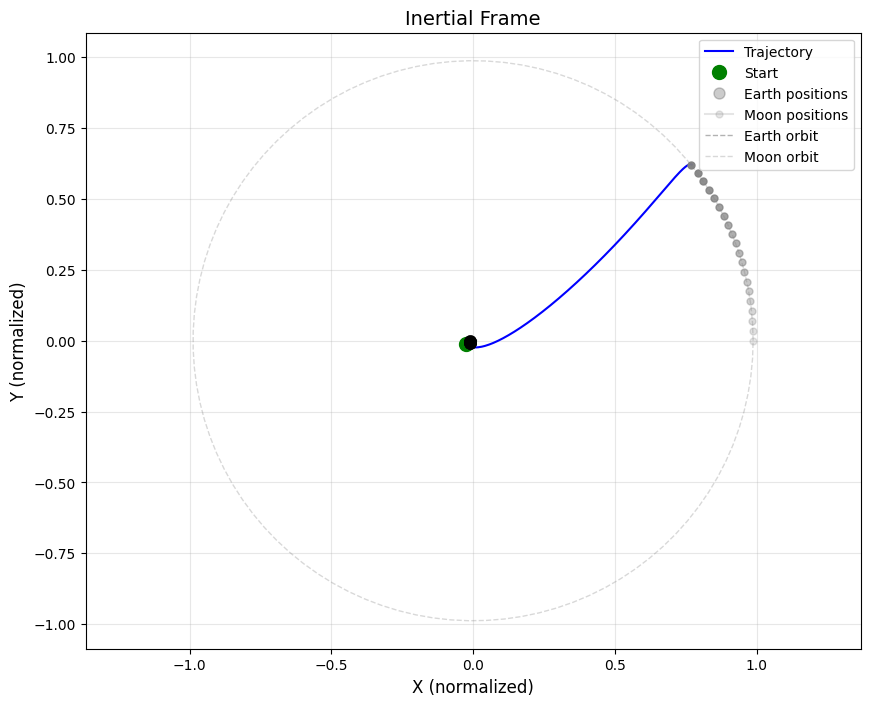

In [21]:
plot_trajectory(states, em.mu, t_eval, frame="Inertial")

## Low Lunar Orbit

In [22]:
moon_f = np.array([1-em.mu,0,0,0,0,0])
moon_f_inertial = em.rotating_to_inertial(moon_f,tof)

tof_llo = 1.5
t_eval_llo = np.arange(tof, tof+tof_llo, 1e-3) # Starts at the end of the previous trajectory, 
#ends at tof+tof_llo, with a step of 1e-3 seconds

states_llo_inertial = ciruclar_orbit_trajectory_moon(em, states_rocket_inertial[:,-1], moon_f_inertial, tof_llo, num_points=len(t_eval_llo))
states_llo_rotating = em.trajectory_inertial_to_rotating(states_llo_inertial, t_eval_llo)

### Plot

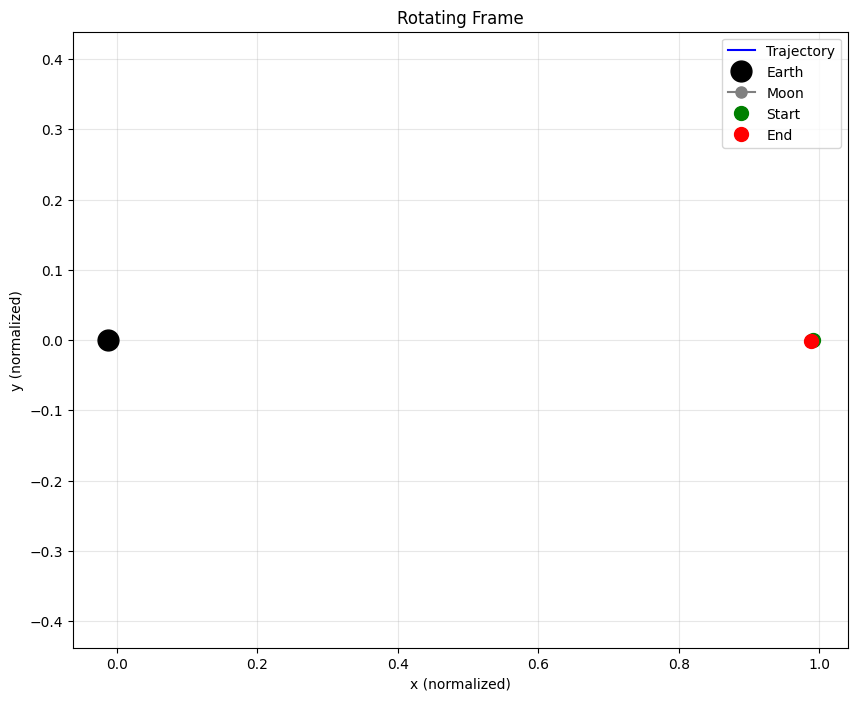

In [23]:
plot_trajectory(states_llo_rotating, em.mu, t_eval_llo, frame="Rotating")

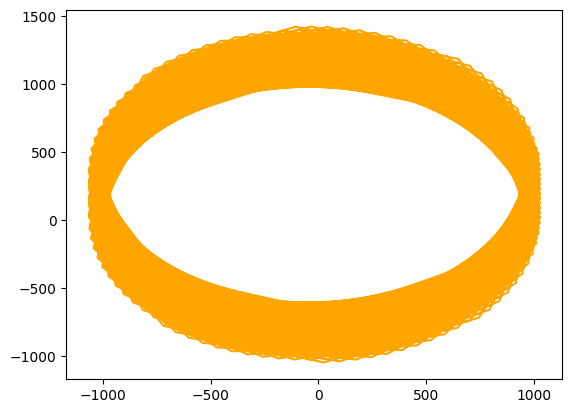

In [24]:
plt.plot(states_llo_rotating[0,:]*em.l_star*1e-3 - 379750, states_llo_rotating[1,:]*em.l_star*1e-3, label="LLMO Orbit", color="orange")

## Combine TLI and LMO

In [25]:
states_full = np.concatenate((states, states_llo_rotating), axis=1) # Concatenate the two trajectories along the time axis (columns)
t_full = np.arange(0, tof+tof_llo, 1e-3) # Starts at 0, ends at tof+tof_llo, with a step of 1e-3 seconds

### Plot

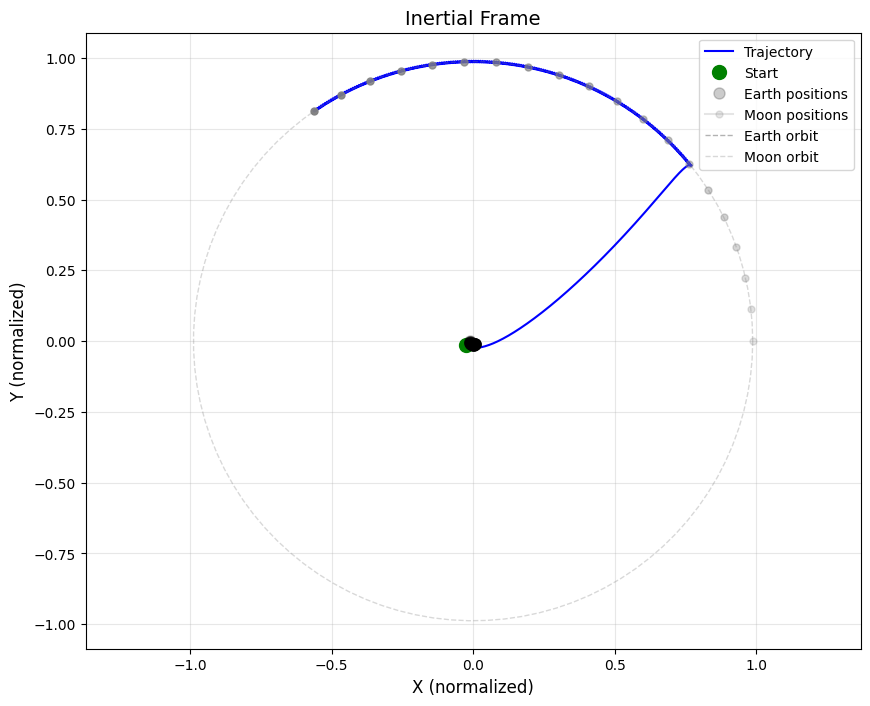

In [26]:
plot_trajectory(states_full, em.mu, t_full, frame="Inertial")

## Load Dataset

In [ ]:
df = np.load("grid_search_results_df.npy", allow_pickle=True)
df = pd.DataFrame(df, columns=["theta", "delta_v", "delta_v_angle", "tof", "objective_value", "distance_to_lmo"])
df['distance_to_lmo'] = abs(df['distance_to_lmo'] * em.l_star)
df.sort_values(by='distance_to_lmo', inplace=True)
optimals = df.iloc[0][0:4].tolist()
print(optimals)
np.save("grid_search_results.npy", optimals) 

[3.908205128205128, 3.0357894736842104, 0.08684210526315789, 0.6561538461538462]


In [29]:
animate = 0
if animate == 1:
    anim = animate_trajectory(em, states_full, t_full, frame='inertial', trail_length=2000)
    from IPython.display import HTML
    HTML(anim.to_html5_video())
    anim.save('trajectory_animation.mp4', writer='ffmpeg', fps=30, dpi=150)